Test Translation Agent

Move This file to Backend folder then execute (import errors)

In [33]:
from Utils.Singleton import Singleton
from config import GEMINI_KEYS, GEMINI_MODEL, CEREBRAS_KEYS, CEREBRAS_MODEL, GROQ_KEYS, GROQ_MODEL
from langgraph.graph import StateGraph, START, END
import json
from typing import TypedDict
from polyrouter import LLMOrchestrator

In [34]:
LLM = LLMOrchestrator(
    groq={
        "groq_models" : GROQ_MODEL,
        "groq_keys" : GROQ_KEYS,
    },
    # gemini={
    #     "gemini_models" : GEMINI_MODEL,
    #     "gemini_keys" : GEMINI_KEYS,
    # },
    cerebras={
        "cerebras_models": CEREBRAS_MODEL,
        "cerebras_keys" : CEREBRAS_KEYS
    },
    debug=1,        # major logs
    verbose=1,      # in-depth trace
    prompt="Be Specific",
    temperature=0.2,
    max_output_tokens=400,
)

In [35]:
class AgentState(TypedDict):
    PREVIOUS_SEGMENT : str
    CURRENT_SEGMENT : str
    FUTURE_SEGMENT : str
    TARGET_LANGUAGE : str
    ITERATIONS : int
    FEEDBACK : str
    TRANSLATED_TEXT : str

In [36]:
def translate_llm(state):
    fb = state.get("FEEDBACK", {})

    feedback_text = ""
    if fb and fb.get('status') == 'INVALID':
        feedback_text = f"""
[PREVIOUS ATTEMPT FEEDBACK]
The validator rejected your last translation for this reason:
"{fb.get('issues')}"

ACTION REQUIRED: Fix this issue in your next output. You must apply this feedback SILENTLY. Do not acknowledge the mistake, do not add notes, and do not include any text other than the final translation.
"""

    prompt = f"""
You are a highly precise contextual translation agent.

Task:
Translate ONLY the text within the [TARGET TO TRANSLATE] block into {state.get('TARGET_LANGUAGE', 'English')}.

Rules:
1. STRICT SCOPE: Do not translate the context blocks.
2. CONTEXT USAGE: Use context blocks strictly to resolve ambiguities (e.g., tone, tense, pronoun resolution).
3. NO FILLER: Output exactly the translated string and nothing else. No conversational text, no brackets, no introductory phrases.

{feedback_text}
--- INPUT DATA ---

[CONTEXT - DO NOT TRANSLATE]
PREVIOUS: {state.get('PREVIOUS_SEGMENT','')}

[CONTEXT - DO NOT TRANSLATE]
FUTURE: {state.get('FUTURE_SEGMENT','')}

[TARGET TO TRANSLATE]
{state.get('CURRENT_SEGMENT','')}
"""

    translated_text = LLM.call(prompt).strip()
    state["TRANSLATED_TEXT"] = translated_text
    return state

In [37]:
def validator_llm(state):

    prompt = f"""
You are a strict translation validation agent.

Task:
Validate whether TRANSLATED_TEXT is an accurate, grammatically correct, and natural translation of ONLY the CURRENT_SEGMENT into {state["TARGET_LANGUAGE"]}.

Rules:
1. FOCUS STRICTLY ON THE TARGET: You must only evaluate the translation of the CURRENT_SEGMENT.
2. HOW TO USE CONTEXT: You are provided with PREVIOUS_SEGMENT and FUTURE_SEGMENT. Use these ONLY to resolve ambiguities in the CURRENT_SEGMENT (e.g., pronoun resolution, maintaining correct tense, or understanding the overall domain). 
3. EXPLICIT NEGATIVE CONSTRAINT: Do NOT penalize the TRANSLATED_TEXT for omitting words, phrases, or concepts that belong to the PREVIOUS_SEGMENT or FUTURE_SEGMENT.
4. Return ONLY valid JSON. Do not return explanations outside JSON.

If translation is correct:
{{
    "status": "VALID",
    "issues": ""
}}

If translation is incorrect:
{{
    "status": "INVALID",
    "issues": "Short reason here, focusing ONLY on errors within the CURRENT_SEGMENT."
}}

--- INPUT DATA ---

[CONTEXT - DO NOT EXPECT THIS TO BE TRANSLATED]
PREVIOUS_SEGMENT:
{state["PREVIOUS_SEGMENT"]}

[TARGET - THIS IS WHAT MUST BE TRANSLATED]
CURRENT_SEGMENT:
{state["CURRENT_SEGMENT"]}

TARGET_LANGUAGE:
{state["TARGET_LANGUAGE"]}

TRANSLATED_TEXT:
{state["TRANSLATED_TEXT"]}

[CONTEXT - DO NOT EXPECT THIS TO BE TRANSLATED]
FUTURE_SEGMENT:
{state["FUTURE_SEGMENT"]}
"""
    validator_res = LLM.call(prompt, json_mode=1)
    state["ITERATIONS"] += 1
    state["FEEDBACK"] = validator_res
    return state

## Testing Nodes

In [38]:
# initial_state = {
#     "PREVIOUS_SEGMENT": "The research team completed the prototype testing phase last week.",
#     "CURRENT_SEGMENT": "The system now processes multilingual audio streams in real time with low latency.",
#     "FUTURE_SEGMENT": "Next, the developers will integrate adaptive voice synthesis and context-aware translation.",
#     "TARGET_LANGUAGE": "Hindi",
#     "ITERATIONS": 0,
#     "FEEDBACK": None,
#     "TRANSLATED_TEXT": ""
# }

In [39]:
# translate_llm(initial_state)

In [40]:
# initial_state

In [41]:
# validator_llm(initial_state)

In [42]:
# initial_state

In [43]:
# print(initial_state["FEEDBACK"]["status"])

## StateGraph

In [44]:
def shouldconitnue(state):
    print(state)
    if(state["FEEDBACK"]["status"] == "VALID"):
        return "end"
    else:
        if(state["ITERATIONS"]>3):
            return "end"
        return "continue"

In [45]:
workflow = StateGraph(AgentState)
workflow.add_node("Translator",translate_llm)
workflow.add_node("Validator",validator_llm)
workflow.add_conditional_edges("Validator",shouldconitnue,
                               {
                                   "end":END,
                                   "continue":"Translator"
                               }

)
workflow.add_edge(START, "Translator")
workflow.add_edge("Translator", "Validator")
app = workflow.compile()

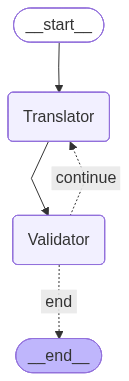

In [46]:
app

In [47]:
initial_state = {
    "PREVIOUS_SEGMENT": "The research team completed the prototype testing phase last week.",
    "CURRENT_SEGMENT": "The system now processes multilingual audio streams in real time with low latency.",
    "FUTURE_SEGMENT": "It will be deployed across edge devices globally.",
    "TRANSLATED_TEXT": "",
    "TARGET_LANGUAGE": "Hindi",
    "ITERATIONS": 0,
    "FEEDBACK": None
}

In [48]:
app.invoke(initial_state)

{'PREVIOUS_SEGMENT': 'The research team completed the prototype testing phase last week.', 'CURRENT_SEGMENT': 'The system now processes multilingual audio streams in real time with low latency.', 'FUTURE_SEGMENT': 'It will be deployed across edge devices globally.', 'TARGET_LANGUAGE': 'Hindi', 'ITERATIONS': 1, 'FEEDBACK': {'status': 'VALID', 'issues': ''}, 'TRANSLATED_TEXT': 'प्रणाली अब वास्तविक समय में कम देरी के साथ बहुभाषी ऑडियो स्ट्रीम को संसाधित करती है।'}


{'PREVIOUS_SEGMENT': 'The research team completed the prototype testing phase last week.',
 'CURRENT_SEGMENT': 'The system now processes multilingual audio streams in real time with low latency.',
 'FUTURE_SEGMENT': 'It will be deployed across edge devices globally.',
 'TARGET_LANGUAGE': 'Hindi',
 'ITERATIONS': 1,
 'FEEDBACK': {'status': 'VALID', 'issues': ''},
 'TRANSLATED_TEXT': 'प्रणाली अब वास्तविक समय में कम देरी के साथ बहुभाषी ऑडियो स्ट्रीम को संसाधित करती है।'}